In [1]:
import numpy as np
import pandas as pd
from plotnine import *
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Image
from scipy.stats import chi2

In [5]:
# Load the yeast data
# We perform some reshapes to make the data easy to use
growth_analysis = pd.read_csv("growth_analysis.txt", sep='\t')
growth_analysis = growth_analysis.rename(
    columns={
        'strain': 'yeast_ID',
        'gene_5211': 'gene_A',
        'gene_5091': 'gene_B',
        'gene_1653': 'gene_C'
    }
)[['yeast_ID', 'growth_rate', 'gene_A', 'gene_B', 'gene_C']]
growth_analysis = pd.melt(
    growth_analysis,
    id_vars=['yeast_ID', 'growth_rate'],
    var_name='gene',
    value_name='variant'
)
growth_analysis['variant'] = growth_analysis['variant'].replace(
    {False: "LAB", True: "WILD"}
)
growth_analysis

,yeast_ID,growth_rate,gene,variant
0,seg_01B,6.720447,gene_A,LAB
1,seg_01C,7.429273,gene_A,LAB
2,seg_01D,6.905589,gene_A,WILD
3,seg_02B,4.924324,gene_A,LAB
4,seg_02C,4.413402,gene_A,LAB
...,...,...,...,...
469,seg_49A,4.592395,gene_C,WILD
470,seg_49B,5.702087,gene_C,LAB
471,seg_50A,4.303382,gene_C,WILD
472,seg_50B,6.583852,gene_C,LAB


## Section 01 - Permutation test of growth rate difference

/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


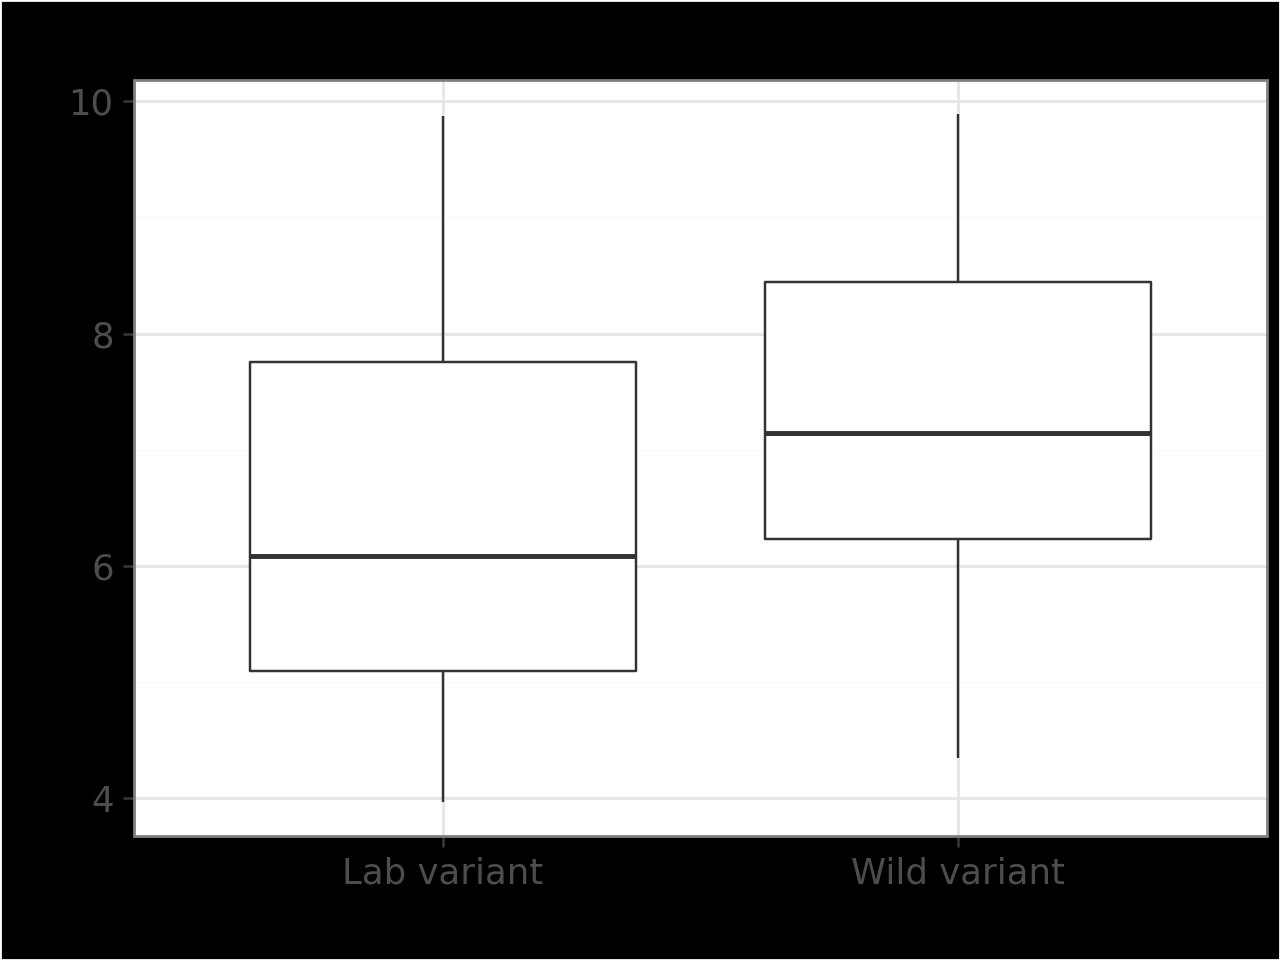

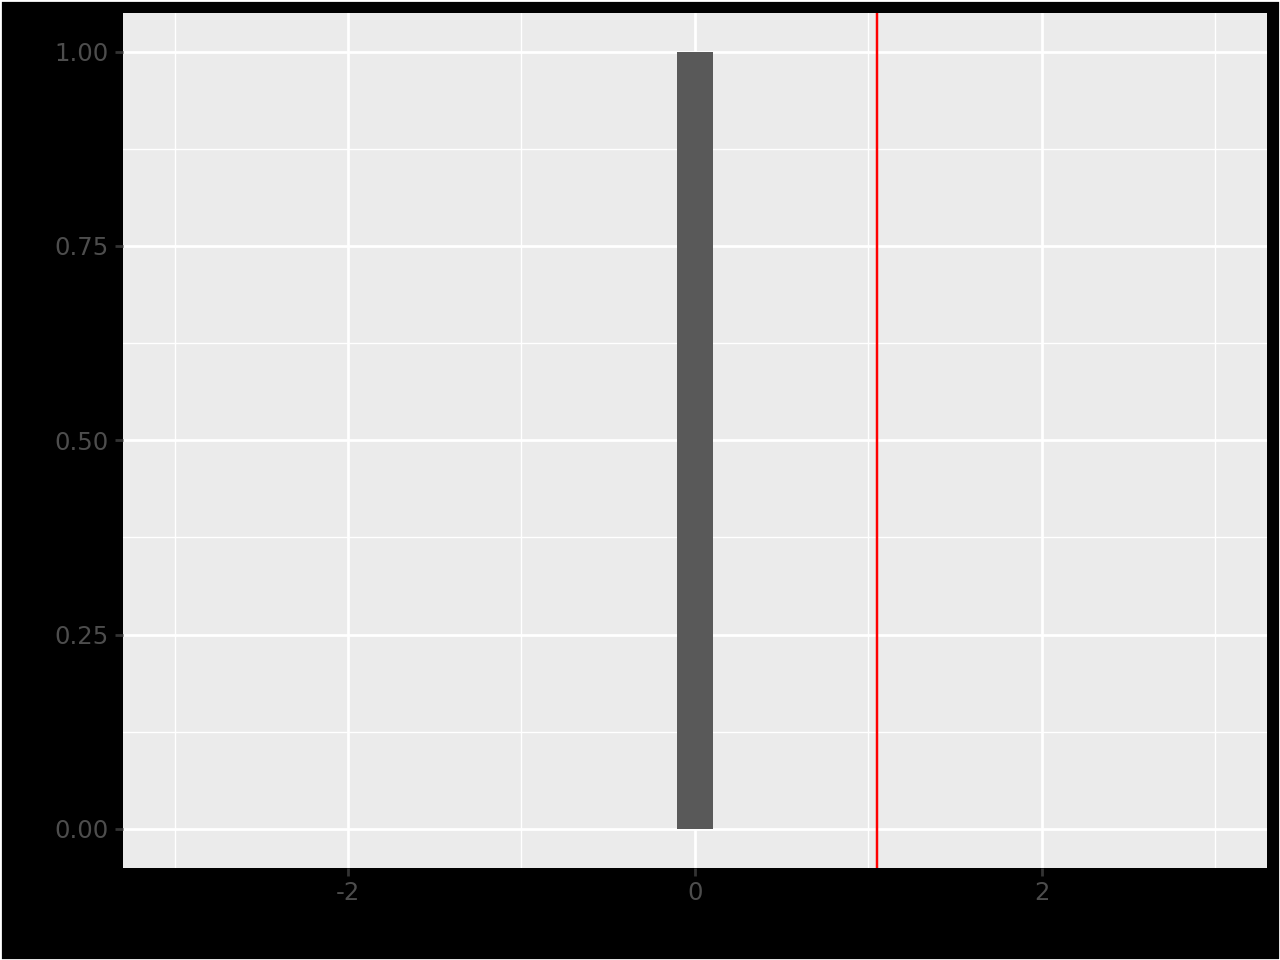

np.float64(0.001998001998001998)

In [7]:
# Function to plot growth vs genotype for one gene
def plot_growth_one_gene(gene_name):
    data = growth_analysis[growth_analysis['gene'] == gene_name]
    g = (
        ggplot(data, aes(x='variant', y='growth_rate'))
        + geom_boxplot()
        + labs(title=f"Growth Rate by {gene_name}", x=gene_name, y="Growth Rate")
        + scale_x_discrete(labels={"LAB": "Lab variant", "WILD": "Wild variant"})
        + theme_bw(base_size=16)
    )
    g.show()
# Function to calculate the difference of the medians of two variants
def median_diff(df):
    medians = df.groupby('variant')['growth_rate'].median()
    return medians['WILD'] - medians['LAB']
# Function to permute the table, plot the resulting histogram and compute a p-value
def p_val_medians(gene_name, N_permu=1000):
# It will return both a pvalue and plot a histogram of T_star
# reduce to gene of interest
    np.random.seed(0)
    df = growth_analysis[growth_analysis['gene'] == gene_name].copy()
    T_ref = median_diff(df)
    # Permutation loop
    T_star = []
    temp_df = df.copy()
    variants = df['variant'].values
    for _ in range(N_permu):
        temp_df['variant'] = np.random.permutation(variants)
    T_star.append(median_diff(temp_df))
    T_star = np.array(T_star)
    # Plotting
    g = (
            ggplot(pd.DataFrame({'T_star': T_star}), aes(x='T_star'))
            + geom_histogram(bins=30)
            + geom_vline(xintercept=T_ref, color='red')
            + xlim(-3, 3)
    )
    g.show()
    # Compute and return the p value
    # First compute each tail seperately
    p_right = (np.sum(T_star >= T_ref) + 1) / (N_permu + 1)
    p_left = (np.sum(T_star <= T_ref) + 1) / (N_permu + 1)
    # Then combine the above to obtain the double sided p-value.
    p_val = 2 * min(p_right, p_left)
    return p_val
# Calling the functions:
plot_growth_one_gene("gene_B")
p_val_medians("gene_B")